In [1]:
from pathlib import Path

import dotenv as dt
from IPython.display import display_html
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

dt.load_dotenv()

import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
path = kagglehub.competition_download('titanic')

In [3]:
df_train = pd.read_csv(Path(path) / 'train.csv')

classes = ['Survived', 'Not Survived']

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


З огляду завантажених даних можемо бачити, що данні неоднорідні (int64, float64, str типип даних) та містять зайву інформацію (колонки PassangerId, Name, Ticket). Прейдемо до подальшого аналізу та нормалізації даних

In [6]:
df_train.isna().sum() / df_train.shape[0]

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [7]:
df_train['Age'] = df_train.apply({ 'Age': lambda x: x.fillna(x.mean()) })

In [8]:
df_train['FamilySize'] = df_train['Parch'] + df_train['SibSp']
df_train.drop(columns=['Parch', 'SibSp'], inplace=True)

In [9]:
df_train.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)
df_train.dropna(axis=0, inplace=True)

In [10]:
df_train.isna().sum() / df_train.shape[0]

Survived      0.0
Pclass        0.0
Sex           0.0
Age           0.0
Fare          0.0
Embarked      0.0
FamilySize    0.0
dtype: float64

In [11]:
df_train.describe()

,Survived,Pclass,Age,Fare,FamilySize
count,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.653446,32.096681,0.906637
std,0.486260,0.834700,12.968366,49.697504,1.614703
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,7.895800,0.000000
50%,0.000000,3.000000,29.699118,14.454200,0.000000
75%,1.000000,3.000000,35.000000,31.000000,1.000000
max,1.000000,3.000000,80.000000,512.329200,10.000000


Після перевірки на наявність пустих значень, бачимо що колонка Cabin майже повністю пуста (77.1% пустих значень). Видаляємо її і також колонки, що не несуть корисно інформації

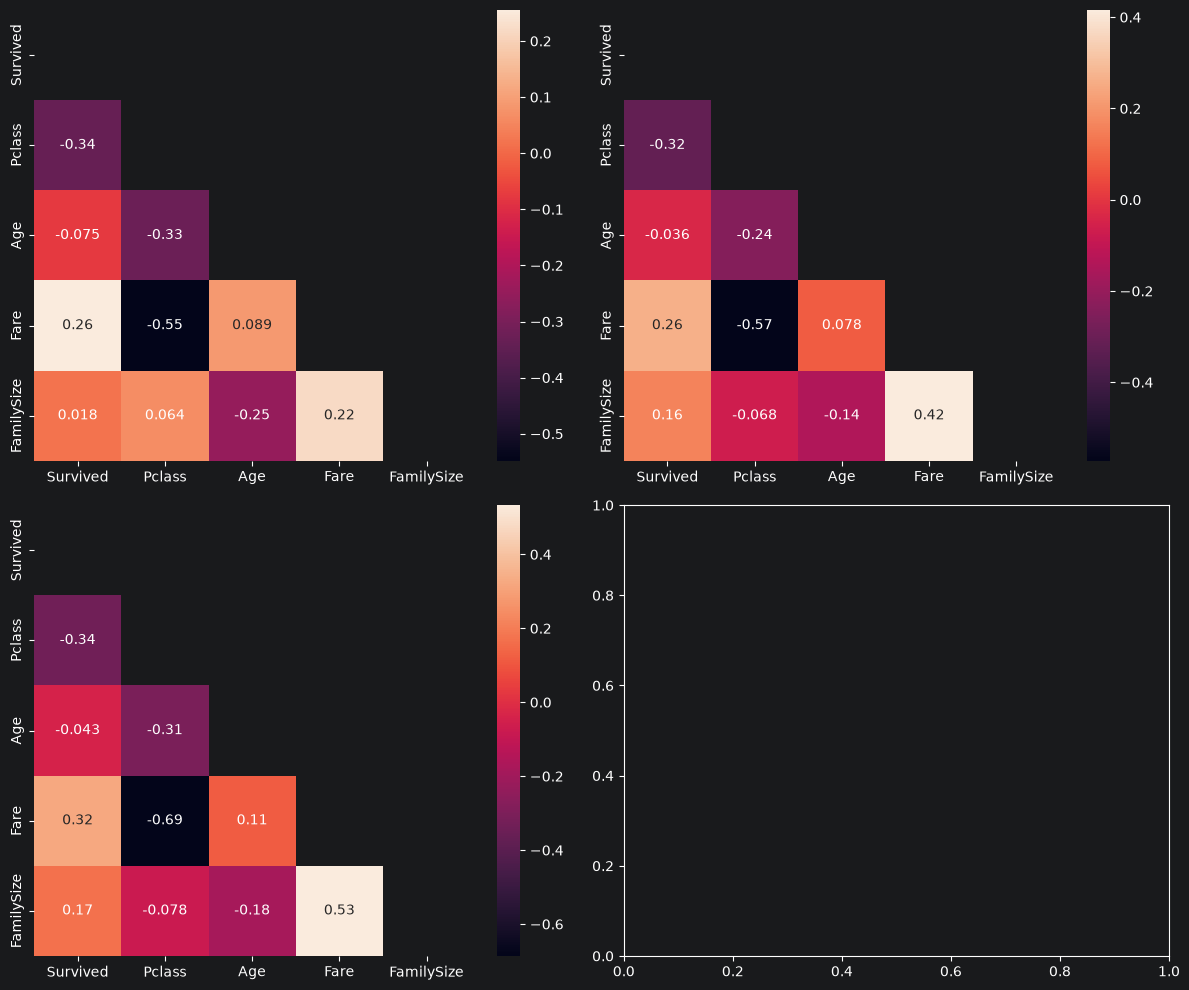

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

mask = np.triu(np.ones_like(df_train.corr(numeric_only=True), dtype=bool))

sns.heatmap(df_train.corr(method='pearson', numeric_only=True), mask=mask, annot=True, ax=axes[0])
sns.heatmap(df_train.corr(method='kendall', numeric_only=True), mask=mask, annot=True, ax=axes[1])
sns.heatmap(df_train.corr(method='spearman', numeric_only=True), mask=mask, annot=True, ax=axes[2])

fig.tight_layout()

Опираючись на аналіз кореляції числових характеристик між собою, можемо сказати, що Fare та Pclass мають достатньо високу негативну кореляцію між собою, що має фізичний сенс за собою - Квитки певного класу будуть різнитися за ціною між собою.

Також можемо бачити невелику замітну кореляцію між класифікаційною рисою та Pclass/Fare.

In [13]:
df_train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


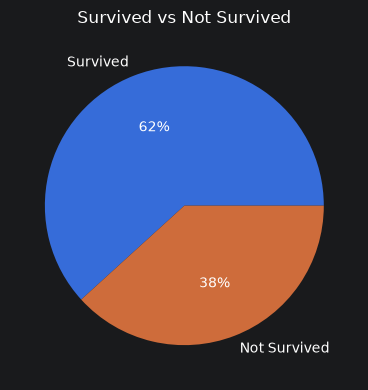

In [14]:
fig, axe = plt.subplots(1, 1, figsize=(12, 4))  # було (12, 10)

pie_data = df_train.groupby('Survived').agg(
    count=("Age", 'count')
)['count']

axe.pie(pie_data, labels=classes, autopct='%.0f%%')
plt.title('Survived vs Not Survived')

plt.tight_layout()
plt.show()

За аналізом розподілу класифікаційнох риси, можемо зробити висновок що розподіл класів задовільний та не потребує додаткового врівноваження

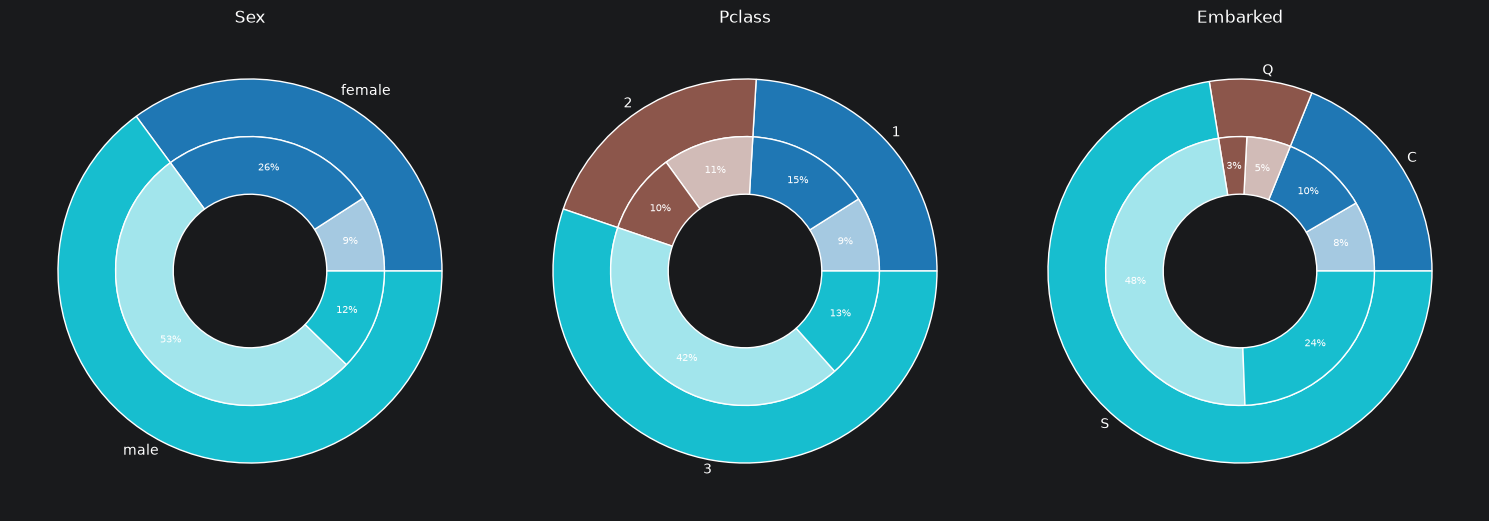

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def lighten(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(c + (white - c) * amount)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.flatten()

columns = ['Sex', 'Pclass', 'Embarked']

for i, column in enumerate(columns):
    ax = axes[i]

    outer_counts = df_train.groupby(column)['Age'].count()
    labels = outer_counts.index.tolist()
    outer_sizes = outer_counts.values

    base_colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    inner_sizes = []
    inner_colors = []
    for idx, cat in enumerate(labels):
        sub = df_train[df_train[column] == cat]['Survived'].value_counts()
        not_surv = sub.get(0, 0)
        surv = sub.get(1, 0)
        inner_sizes += [not_surv, surv]
        inner_colors += [lighten(base_colors[idx], 0.6), base_colors[idx]]

    ax.pie(
        outer_sizes, labels=labels, colors=base_colors,
        radius=1, wedgeprops=dict(width=0.3, edgecolor='white'),
        labeldistance=1.05
    )

    ax.pie(
        inner_sizes, colors=inner_colors,
        radius=0.7, wedgeprops=dict(width=0.3, edgecolor='white'),
        autopct='%.0f%%', pctdistance=0.78, textprops={'fontsize': 7}
    )

    ax.set_title(column)

plt.tight_layout()
plt.show()

Виходячи з отриманих графіків, бачимо що найбільш велика частка тих, то вижив це жінки та люди у першому класі.

Також видно що велика частка людей, що зайшли на борт у порту Southampton не вижила. Це можна пояснити тим, що у цьому порту сіла переважна кількість людей з білетом у третій клас [(джерело)](https://medium.com/@praveen.orvakanti/surviving-the-titanic-f28b39a7b10f)

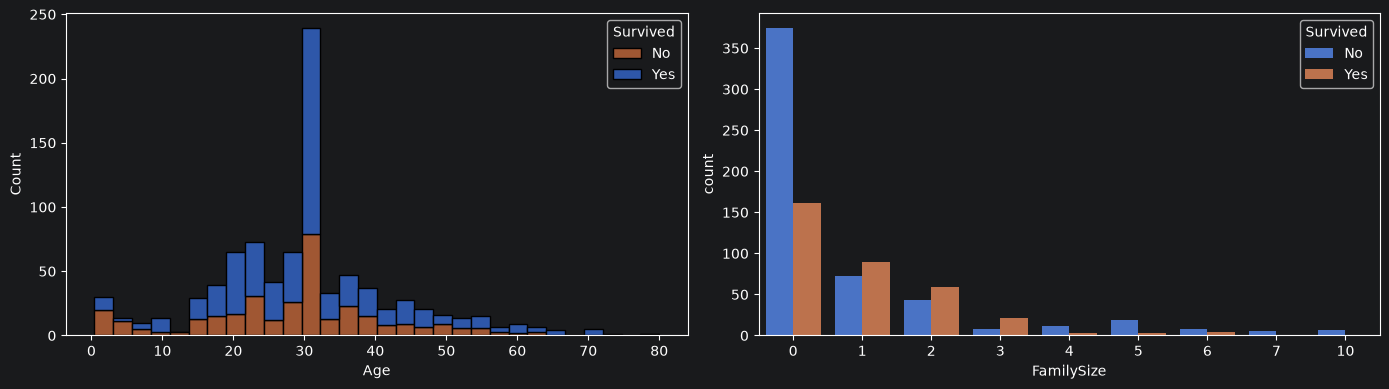

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes = axes.flatten()

sns.histplot(
    data=df_train, x='Age', bins=30, hue='Survived',
    multiple='stack', ax=axes[0]
)
sns.countplot(
    data=df_train, x='FamilySize', hue='Survived', ax=axes[1]
)

for ax in axes:
    ax.legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

З проведеного аналізу, можемо зробити припущення, що такі характеристики, як Стать, Клас білету та Вік є найважливішими у для класифікації. Так ідеальний портрет людини, що вижила це - Жінка, приблизно 30 років, маж білет у перший клас та не має родичів на борту.

Для подальшого моделювання, проведемо кодування категоріальних характеристик за допомогою OneHotEncoder та нормалізацію значень через StandardScaler. Побудуємо три моделі, побудовані на LogisticRegression, SVC відповідно, та використаємо підбір гіперпараметрів через GridSearchCV. Порівняємо їх результати

In [17]:
df_train = df_train.reset_index(drop=True)

encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
to_encode = ['Sex', 'Embarked']

encoded = encoder.fit_transform(df_train[to_encode])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(to_encode))

df_train = pd.concat([df_train.drop(columns=to_encode), encoded_df], axis=1)

In [18]:
df_train.head()

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,7.2500,1,1.0,0.0,0.0,1.0
1,1,1,38.0,71.2833,1,0.0,1.0,0.0,0.0
2,1,3,26.0,7.9250,0,0.0,0.0,0.0,1.0
3,1,1,35.0,53.1000,1,0.0,0.0,0.0,1.0
4,0,3,35.0,8.0500,0,1.0,0.0,0.0,1.0


In [19]:
X = df_train.drop(columns='Survived')
y = df_train['Survived']

features = X.columns.to_numpy()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

In [21]:
param_grid = [
    {
        'l1_ratio': [0.0],
        'solver': ['lbfgs'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [1000, 5000],
    },
    {
        'l1_ratio': [0.0, 1.0],
        'solver': ['liblinear'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [1000, 5000],
    },
    {
        'l1_ratio': np.arange(0.0, 1.1, 0.1),
        'solver': ['saga'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [1000, 5000],
    },
]

log_classifier = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
log_classifier.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': array([1.0000...00000000e+04]), 'l1_ratio': [0.0], 'max_iter': [1000, 5000], 'solver': ['lbfgs']}, {'C': array([1.0000...00000000e+04]), 'l1_ratio': [0.0, 1.0], 'max_iter': [1000, 5000], 'solver': ['liblinear']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomp

In [22]:
y_pred = log_classifier.predict(X_test)

log_cm = confusion_matrix(y_test, y_pred)
log_accuracy = accuracy_score(y_test, y_pred)
log_report = classification_report(y_test, y_pred, output_dict=True, target_names=classes, zero_division=False)
log_premutation = permutation_importance(log_classifier, X_test, y_test, n_repeats=10, random_state=42)

In [23]:
param_grid = [
    {
        'kernel': ['rbf'],
        'C': np.logspace(-3, 3, 13),
        'gamma': np.logspace(-4, 1, 10),
    },
]

svc_classifier = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
)
svc_classifier.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+01]), 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [24]:
y_pred = svc_classifier.predict(X_test)

svc_cm = confusion_matrix(y_test, y_pred)
svc_accuracy = accuracy_score(y_test, y_pred)
svc_report = classification_report(y_test, y_pred, output_dict=True, target_names=classes, zero_division=False)
svc_premutation = permutation_importance(svc_classifier, X_test, y_test, n_repeats=10, random_state=42)

In [25]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced'],
}

tree_classifier = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
)
tree_classifier.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callabl

In [26]:
y_pred = tree_classifier.predict(X_test)

tree_cm = confusion_matrix(y_test, y_pred)
tree_accuracy = accuracy_score(y_test, y_pred)
tree_report = classification_report(y_test, y_pred, output_dict=True, target_names=classes, zero_division=False)
tree_premutation = permutation_importance(tree_classifier, X_test, y_test, n_repeats=10, random_state=42)

In [27]:
reports = {
    'Logistic Regression': log_report,
    'Support Vectors': svc_report,
    'Random Forest': tree_report,
}

dfs = {name: pd.DataFrame(rep).T.round(3) for name, rep in reports.items()}
pd.concat(dfs, axis=1)

Logistic Regression                          Support Vectors  \
                       precision recall f1-score  support       precision   
Survived                   0.840  0.817    0.828  109.000           0.848   
Not Survived               0.722  0.754    0.738   69.000           0.788   
accuracy                   0.792  0.792    0.792    0.792           0.826   
macro avg                  0.781  0.785    0.783  178.000           0.818   
weighted avg               0.794  0.792    0.793  178.000           0.825   

                                      Random Forest                           
             recall f1-score  support     precision recall f1-score  support  
Survived      0.872    0.860  109.000         0.849  0.826    0.837  109.000  
Not Survived  0.754    0.770   69.000         0.736  0.768    0.752   69.000  
accuracy      0.826    0.826    0.826         0.803  0.803    0.803    0.803  
macro avg     0.813    0.815  178.000         0.793  0.797    0.794  178.000  
weighted avg  0.826    0.825  178.000         0.805  0.803    0.804  178.000

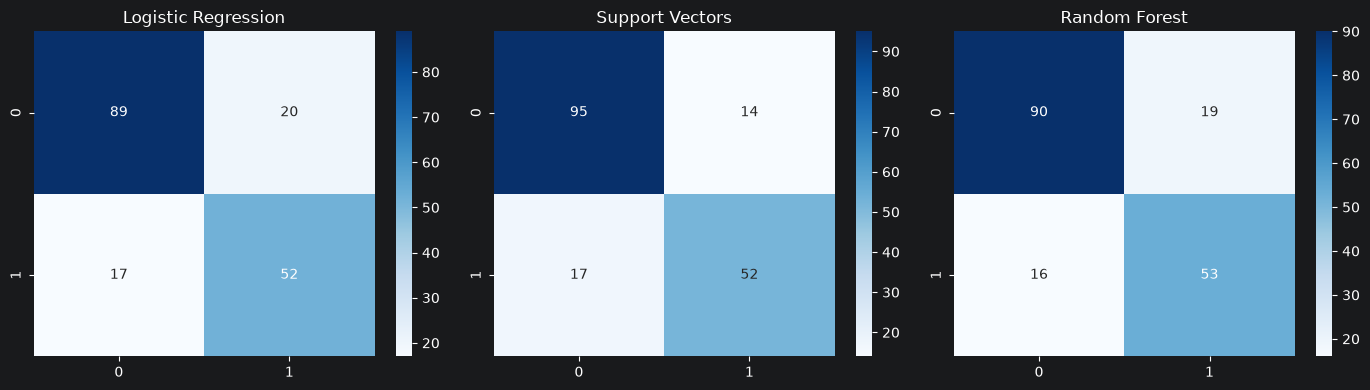

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')

sns.heatmap(svc_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Support Vectors')

sns.heatmap(tree_cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Random Forest')

plt.tight_layout()
plt.show()

In [29]:
models = {
    "RandomForest": tree_classifier,
    "LogisticRegression": log_classifier,
    "SVC": svc_classifier,
}

X_test, y_test = X_test, y_test
feature_names = features

n_repeats = 10
random_state = 42
scoring = "f1"

results = {}

for name, model in models.items():
    r = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring=scoring,
        n_jobs=-1
    )
    results[name] = pd.Series(r.importances_mean, index=feature_names)

importance_df = pd.DataFrame(results)
importance_df["mean_across_models"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean_across_models", ascending=False)


top_n = 5
print(f"\nТоп-{top_n} ознак по кожній моделі:\n")
for name in models:
    top_features = importance_df[name].sort_values(ascending=False).head(top_n)
    print(f"{name}:")
    for feat, val in top_features.items():
        print(f"  {feat}: {val:.4f}")
    print()


Топ-5 ознак по кожній моделі:

RandomForest:
  Sex_male: 0.2664
  Pclass: 0.0665
  Age: 0.0584
  Fare: 0.0398
  Embarked_S: 0.0042

LogisticRegression:
  Sex_male: 0.2806
  Pclass: 0.0314
  Age: 0.0199
  Fare: 0.0027
  Embarked_Q: 0.0000

SVC:
  Sex_male: 0.3259
  Pclass: 0.0373
  Age: 0.0243
  FamilySize: 0.0159
  Fare: 0.0132



Аналізуючи результати отриманих моделей, опираючись на метрику f1-score, можемо визначити що модель побудована на базі SVC має найкращі резільтати. Дана модель має найкраще співвідношення precision та recall. Також видно, що дана модель має найменшу кількіст неправильно класифікованих кейсів

Переходячи до важливості параметрів, можемо зробити висновок, що теорія про важливіть таких параметрів як Стать, Клас білету та Вік підтрердилася.

In [59]:
df_test = pd.read_csv(Path(path) / 'test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [60]:
df_test['Age'] = df_test.apply({'Age': lambda x: x.fillna(x.mean())})
df_test['Fare'] = df_test.apply({'Fare': lambda x: x.fillna(x.mean())})
df_test['FamilySize'] = df_test['Parch'] + df_test['SibSp']
df_test.drop(columns=['Parch', 'SibSp'], inplace=True)
df_test.drop(columns=['Cabin', 'Name', 'Ticket'], inplace=True)

result_df = df_test[['PassengerId']]
df_test.drop(columns=['PassengerId'], inplace=True)

df_test.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,3,male,34.5,7.8292,Q,0
1,3,female,47.0,7.0000,S,1
2,2,male,62.0,9.6875,Q,0
3,3,male,27.0,8.6625,S,0
4,3,female,22.0,12.2875,S,2


In [61]:
df_test = df_test.reset_index(drop=True)

encoded = encoder.transform(df_test[to_encode])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(to_encode))
df_test = pd.concat([df_test, encoded_df], axis=1)
df_test.drop(columns=to_encode, inplace=True)

df_test.head()

,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,34.5,7.8292,0,1.0,0.0,1.0,0.0
1,3,47.0,7.0000,1,0.0,0.0,0.0,1.0
2,2,62.0,9.6875,0,1.0,0.0,1.0,0.0
3,3,27.0,8.6625,0,1.0,0.0,0.0,1.0
4,3,22.0,12.2875,2,0.0,0.0,0.0,1.0


In [62]:
X = scaler.transform(df_test)
y_final = svc_classifier.predict(X)
y_final


array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [63]:
result_df = result_df.reset_index(drop=True)
result_df['Survived'] = pd.Series(y_final)
result_df.to_csv('outputs/titanic_submission.csv', index=False)